# Exploratory Data Analysis (EDA)

## Travel Analytics MLOps Project

This notebook explores the Users, Flights, and Hotels datasets to identify
patterns, relationships, trends, and important features for the machine
learning models.

In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

In [31]:
users = pd.read_csv("../data/raw/users.csv")
flights = pd.read_csv("../data/raw/flights.csv")
hotels = pd.read_csv("../data/raw/hotels.csv")

In [32]:
print("Users shape   :", users.shape)
print("Flights shape :", flights.shape)
print("Hotels shape  :", hotels.shape)

##This is just a quick confirmation that our EDA notebook is working with the same datasets.

Users shape   : (1340, 5)
Flights shape : (271888, 10)
Hotels shape  : (40552, 8)


## 1. Flight Price Analysis

The objective of this section is to understand the distribution of flight
prices and investigate the factors that may influence flight prices.

These findings will help us select relevant features for the Flight Price
Prediction model.

## 1.1 Flight Price Distribution

### 1.1.1 Flight Price Distribution by Price Range

In [33]:
# Creating price bins
price_bins = [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800]

price_labels = ['200-400', '400-600', '600-800', '800-1000', '1000-1200', '1200-1400', '1400-1600', '1600-1800']

# Creating price range column
flights['price_range'] = pd.cut(flights['price'], 
                              bins = price_bins, 
                              labels = price_labels, 
                              include_lowest= True)

# Creating frequency table
price_distribution = (flights["price_range"].value_counts().sort_index().reset_index())

price_distribution.columns = ["Price Range", "Number Of Flights"]
price_distribution

,Price Range,Number Of Flights
0,200-400,9747
1,400-600,40289
2,600-800,53557
3,800-1000,57150
4,1000-1200,38946
5,1200-1400,34591
6,1400-1600,24740
7,1600-1800,12868


In [34]:
price_distribution["Percentage"] = (price_distribution["Number Of Flights"]/len(flights)*100).round(2)
price_distribution

,Price Range,Number Of Flights,Percentage
0,200-400,9747,3.58
1,400-600,40289,14.82
2,600-800,53557,19.70
3,800-1000,57150,21.02
4,1000-1200,38946,14.32
5,1200-1400,34591,12.72
6,1400-1600,24740,9.10
7,1600-1800,12868,4.73


### 1.1.2 Flight Price Distribution (Histogram)

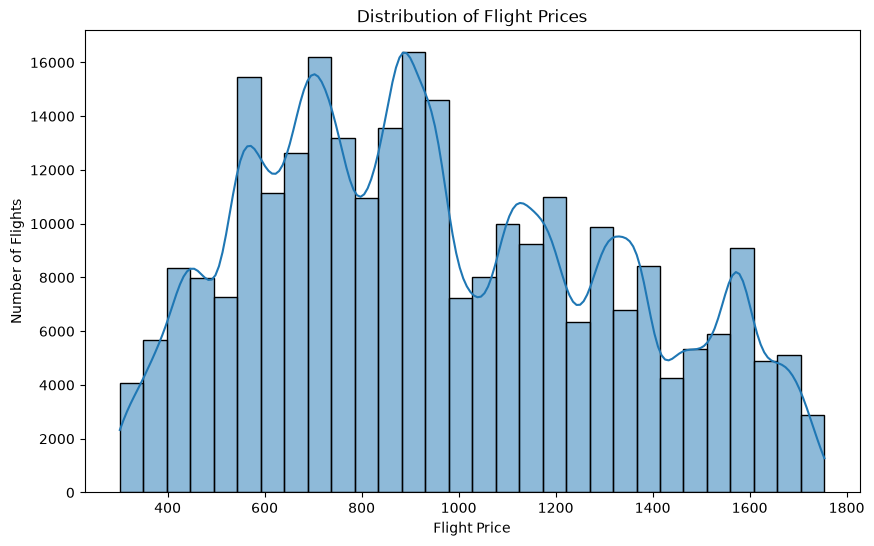

In [35]:
plt.figure(figsize=(10, 6))

sns.histplot(
    flights["price"],
    bins=30,
    kde=True
)

plt.title("Distribution of Flight Prices")
plt.xlabel("Flight Price")
plt.ylabel("Number of Flights")

plt.show()

### Observation

The flight prices are mainly concentrated in the $400–$1,200 range, which accounts for 69.86% of all flights. The highest concentration is observed in the $800–$1,000 range, with 57,150 flights (21.02%), followed by the $600–$800 range with 53,557 flights (19.70%). The $400–$600 range contains 40,289 flights (14.82%), while the $1,000–$1,200 range contains 38,946 flights (14.32%). The number of flights generally decreases beyond $1,200, with 34,591 flights (12.72%) in the $1,200–$1,400 range and 24,740 flights (9.10%) in the $1,400–$1,600 range. Only 12,868 flights (4.73%) fall within the $1,600–$1,800 range, while 9,747 flights (3.58%) are in the lowest $200–$400 range. Overall, the distribution shows that mid-range flight prices are the most common, with relatively fewer flights at the lower and higher ends of the price range.

## 1.2 Flight Price Statistics

In [36]:
flights["price"].describe()

count    271888.00000
mean        957.37503
std         362.31189
min         301.51000
25%         672.66000
50%         904.00000
75%        1222.24000
max        1754.17000
Name: price, dtype: float64

## 1.3 Flight Price by Flight Type

### 1.3.1 Flight Price Summary by Flight Type

In [37]:
flight_type_summary = flights.groupby("flightType")["price"].agg(
    Number_of_flights = "count",
    Average_price = "mean",
    Median_price = "median",
    Minimum_price = "min",
    Maximum_price = "max").round(2).reset_index()
flight_type_summary

,flightType,Number_of_flights,Average_price,Median_price,Minimum_price,Maximum_price
0,economic,77466,658.44,674.52,301.51,972.12
1,firstClass,116418,1181.07,1190.94,539.39,1754.17
2,premium,78004,920.39,932.84,427.25,1370.17


### 1.3.2 Flight Price Distribution by Flight Type

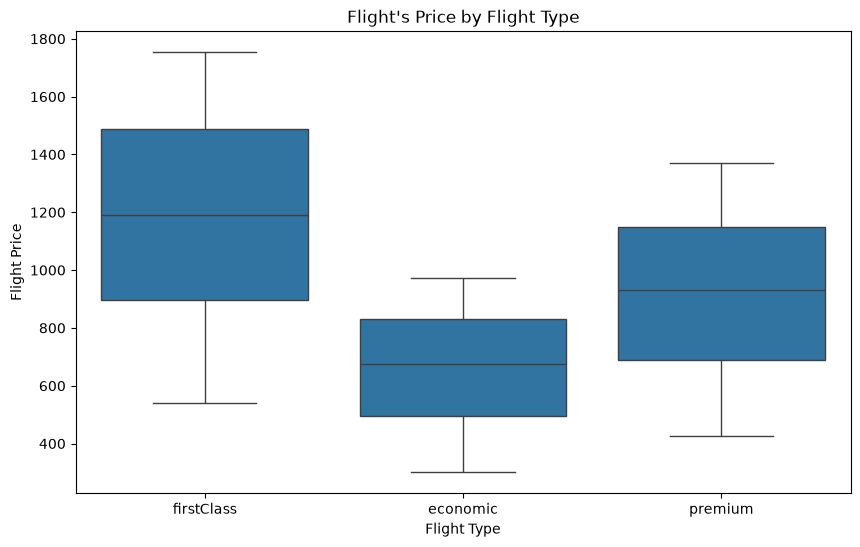

In [38]:
plt.figure(figsize= (10, 6))
sns.boxplot(data = flights, x = "flightType", y = "price")
plt.title("Flight's Price by Flight Type")
plt.xlabel("Flight Type")
plt.ylabel("Flight Price")
plt.show()

### Observation

First-class flights have the highest average price ($1,181.07), followed by premium flights ($920.39), while economic flights have the lowest average price ($658.44). The median prices show a similar pattern, indicating that flight type is strongly associated with flight price. First-class flights also have the widest price range, from $539.39 to $1,754.17, suggesting greater price variability compared with economic and premium flights.

## 1.4 Flight Price by Distance

We investigate whether flight prices vary with travel distance. This analysis
helps determine whether distance is an important feature for the flight price
prediction model.

### 1.4.1 Flight Price Summary by Distance Range

In [39]:
distance_bins = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
distance_labels = ["100-200", "200-300", "300-400", "400-500", "500-600", "600-700", "700-800", "800-900", "900-1000"]

flights["distance_ranges"] = pd.cut(flights['distance'], 
                                    bins = distance_bins,
                                    labels = distance_labels,
                                    include_lowest= True)

In [40]:
distance_summary = flights.groupby("distance_ranges", observed = False)["price"].agg(Number_of_flights = "count",
                                                                                     Average_price = 'mean',
                                                                                     Median_prince = 'median').round(2).reset_index()
distance_summary

,distance_ranges,Number_of_flights,Average_price,Median_prince
0,100-200,19056,494.69,479.37
1,200-300,35228,673.56,661.32
2,300-400,13164,796.14,752.27
3,400-500,29062,792.84,721.20
4,500-600,67278,961.07,932.22
5,600-700,45580,1099.14,1087.18
6,700-800,19174,1187.10,1212.58
7,800-900,31746,1274.60,1288.79
8,900-1000,11600,1348.25,1336.68


### 1.4.2 Relationship Between Distance and Flight Price

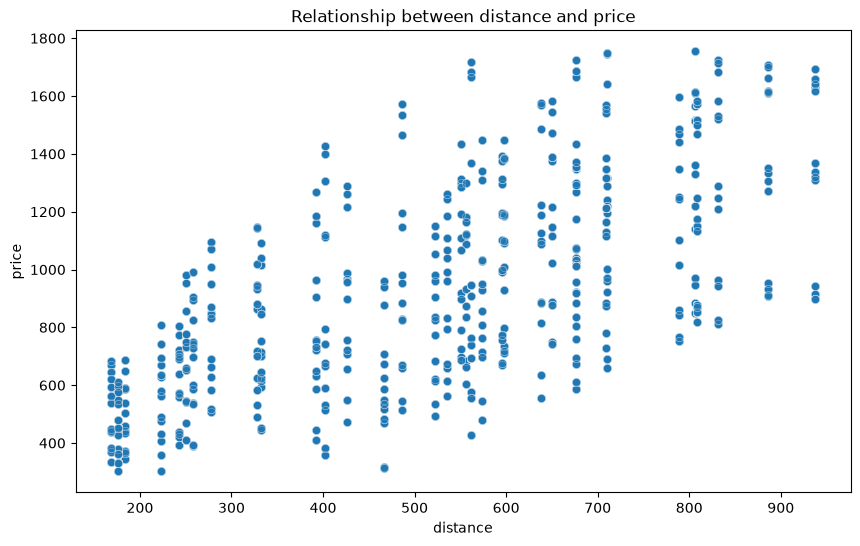

In [41]:
plt.figure(figsize = (10, 6))
sns.scatterplot(data = flights,
                x = "distance",
                y = "price",
                alpha = 0.3)

plt.title("Relationship between distance and price")
plt.xlabel("distance")
plt.ylabel("price")
plt.show()

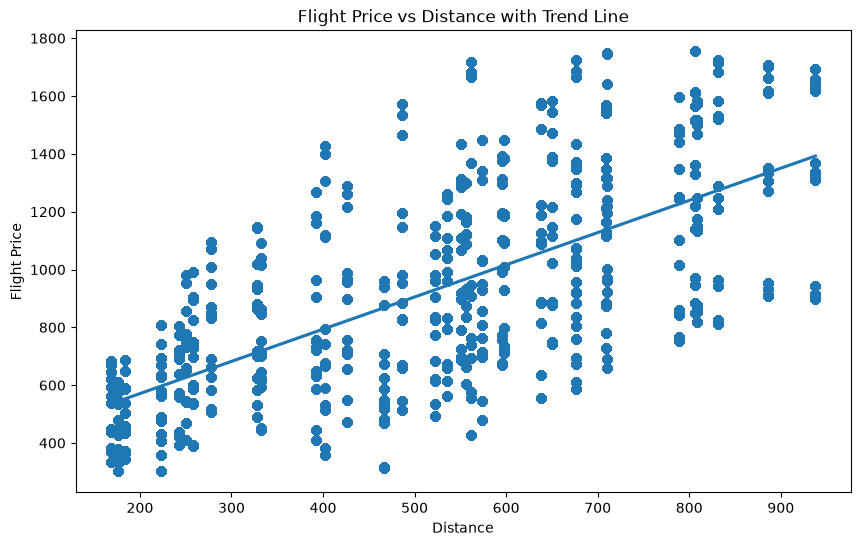

In [42]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=flights,
    x="distance",
    y="price",
    scatter_kws={"alpha": 0.2},
    line_kws={}
)

plt.title("Flight Price vs Distance with Trend Line")
plt.xlabel("Distance")
plt.ylabel("Flight Price")

plt.show()

### Observation

Flight price generally increases as distance increases. The average price rises from $494.69 for flights covering 100–200 units of distance to $1,348.25 for flights covering 900–1,000 units. The scatter plot also shows a clear positive relationship between distance and price, although there is considerable variation at individual distance levels. This indicates that distance is likely to be an important feature for flight price prediction.

## 1.5 Flight Price by Flight Duration

We investigate whether flight duration is associated with flight price.

In [44]:
flights["time"].head()

0    1.76
1    1.76
2    1.66
3    1.66
4    2.16
Name: time, dtype: float64

In [45]:
flights["time"].describe()

count    271888.000000
mean          1.421147
std           0.542541
min           0.440000
25%           1.040000
50%           1.460000
75%           1.760000
max           2.440000
Name: time, dtype: float64

In [46]:
flights["time"].nunique()

33

In [49]:
time_bins = [0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8]

time_ranges = ["0.4-0.8", "0.8-1.2", "1.2-1.6", "1.6-2.0", "2.0-2.4", "2.4-2.8"]

flights["time_range"] = pd.cut(flights["time"], bins = time_bins, labels = time_ranges, include_lowest = True)

In [51]:
time_summary = flights.groupby("time_range", observed = False)["price"].agg(
    Number_of_flights = "count",
    Average_price = "mean",
    Median_price = "median").round(2).reset_index()

time_summary

,time_range,Number_of_flights,Average_price,Median_price
0,0.4-0.8,54284,610.77,586.06
1,0.8-1.2,24788,835.25,756.30
2,1.2-1.6,84716,914.55,883.63
3,1.6-2.0,60850,1120.69,1116.83
4,2.0-2.4,35650,1265.91,1270.03
5,2.4-2.8,11600,1348.25,1336.68


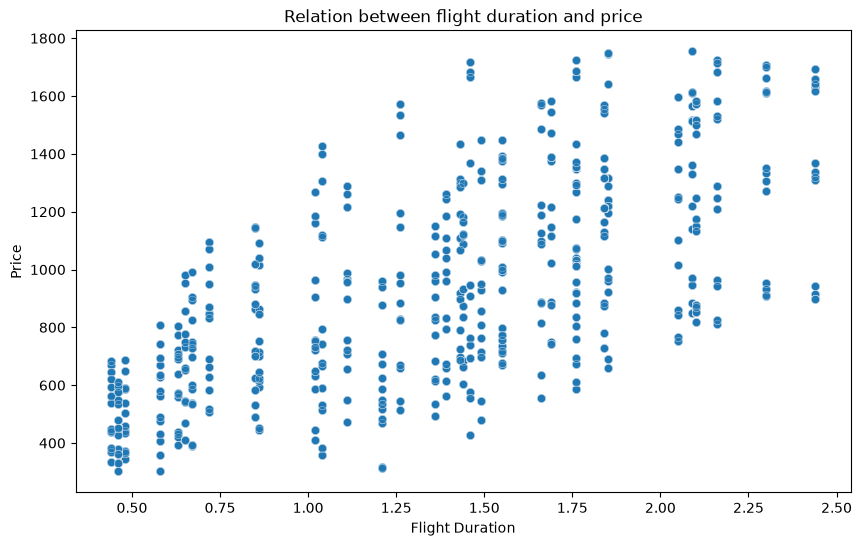

In [52]:
plt.figure(figsize = (10,6))

sns.scatterplot(data = flights, x = "time", y = "price", alpha = 0.3)
plt.title("Relation between flight duration and price")
plt.xlabel("Flight Duration")
plt.ylabel("Price")
plt.show()

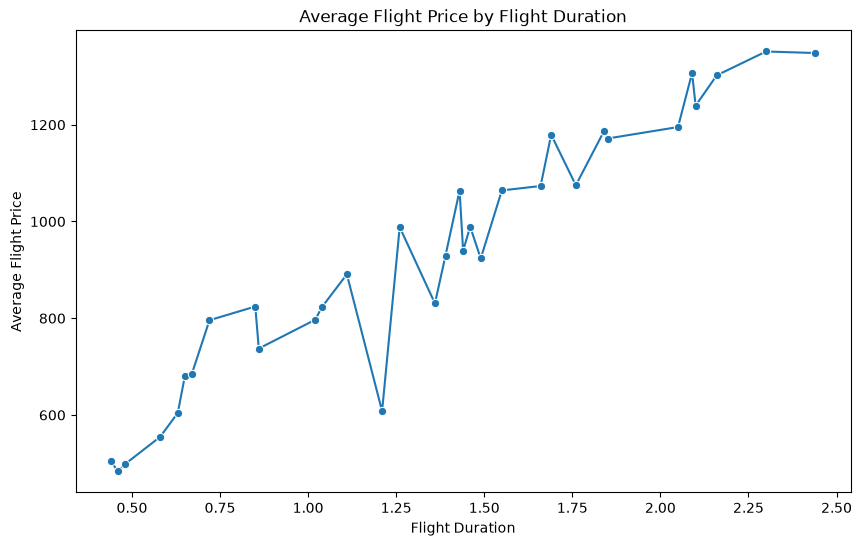

In [53]:
time_price = (
    flights.groupby("time")["price"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=time_price,
    x="time",
    y="price",
    marker="o"
)

plt.title("Average Flight Price by Flight Duration")
plt.xlabel("Flight Duration")
plt.ylabel("Average Flight Price")

plt.show()

### Observation

Flight price generally increases with flight duration. The average price rises from $610.77 for flights lasting 0.4–0.8 hours to $1,348.25 for flights lasting 2.4–2.8 hours. The line plot confirms this overall upward trend, although some shorter-duration groups show fluctuations. This suggests that flight duration is an important feature for flight price prediction.

## 1.6 Flight Price by Agency

We investigate whether flight prices vary across different flight agencies.

In [55]:
agency_summary = flights.groupby("agency")["price"].agg(Number_of_flights = "count",
                                                        Average_price = "mean",
                                                        Median_price = "median",
                                                        Minimum_price = "min",
                                                        Maximum_price = 'max').round(2).reset_index()

agency_summary

,agency,Number_of_flights,Average_price,Median_price,Minimum_price,Maximum_price
0,CloudFy,116378,918.90,883.63,301.51,1747.31
1,FlyingDrops,38758,1186.16,1269.73,539.39,1744.87
2,Rainbow,116752,919.78,870.91,301.61,1754.17


### 1.6.1 Average Flight Price by Agency

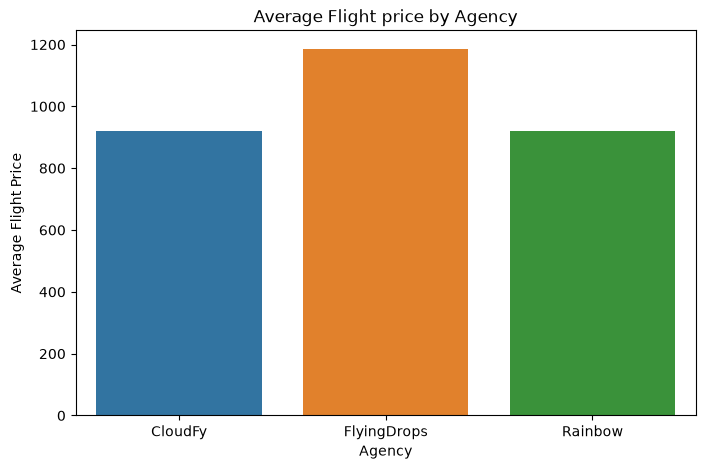

In [57]:
plt.figure(figsize = (8, 5))

sns.barplot(data = agency_summary, x = "agency", y = "Average_price", hue = 'agency', legend = False)
plt.title("Average Flight price by Agency")
plt.xlabel("Agency")
plt.ylabel("Average Flight Price")

plt.show()

### Observations

FlyingDrops has the highest average flight price at $1,186.16, compared with $918.90 for CloudFy and $919.78 for Rainbow. CloudFy and Rainbow have almost identical average prices, while FlyingDrops is noticeably more expensive on average.

## 1.7 Flight Price by Route

In this analysis, we examine how flight prices vary across different origin-destination routes. We also compare the most frequently used routes to identify whether certain routes have higher average flight prices.

### 1.7.1 Create Route Feature

We combine the origin and destination cities to create a route variable in the format `Origin → Destination`.

In [67]:
flights["route"] = flights["from"] + " → " + flights["to"]
flights[["from", "to", "route"]].head()

,from,to,route
0,Recife (PE),Florianopolis (SC),Recife (PE) → Florianopolis (SC)
1,Florianopolis (SC),Recife (PE),Florianopolis (SC) → Recife (PE)
2,Brasilia (DF),Florianopolis (SC),Brasilia (DF) → Florianopolis (SC)
3,Florianopolis (SC),Brasilia (DF),Florianopolis (SC) → Brasilia (DF)
4,Aracaju (SE),Salvador (BH),Aracaju (SE) → Salvador (BH)


### 1.7.2 Most Frequently Used Routes

We identify the routes with the highest number of flights to understand the most common travel patterns in the dataset.

In [70]:
route_frequency = (flights["route"].value_counts().reset_index())
route_frequency.clumns = ["route", "Number_of_flights"]

route_frequency.head(10)

,route,count
0,Aracaju (SE) → Florianopolis (SC),8643
1,Florianopolis (SC) → Aracaju (SE),8643
2,Campo Grande (MS) → Florianopolis (SC),8253
3,Florianopolis (SC) → Campo Grande (MS),8253
4,Brasilia (DF) → Florianopolis (SC),7779
5,Florianopolis (SC) → Brasilia (DF),7779
6,Recife (PE) → Florianopolis (SC),7609
7,Florianopolis (SC) → Recife (PE),7609
8,Sao Paulo (SP) → Florianopolis (SC),6717
9,Florianopolis (SC) → Sao Paulo (SP),6717


### 1.7.3 Flight Price by Route

We calculate the number of flights, average price, and median price for each route. The analysis is limited to the top 10 most frequently used routes to make the comparison meaningful and easy to interpret.

In [73]:
route_summary = flights.groupby("route")["price"].agg(
    Number_of_flights = "count",
    Average_price = "mean",
    Median_price = "median").round(2).reset_index()

route_summary = (route_summary.sort_values("Number_of_flights", ascending = False).head(10))

route_summary

,route,Number_of_flights,Average_price,Median_price
2,Aracaju (SE) → Florianopolis (SC),8643,1232.44,1174.97
24,Florianopolis (SC) → Aracaju (SE),8643,1246.37,1248.70
18,Campo Grande (MS) → Florianopolis (SC),8253,1106.75,1031.59
26,Florianopolis (SC) → Campo Grande (MS),8253,740.47,714.86
10,Brasilia (DF) → Florianopolis (SC),7779,1260.25,1222.24
25,Florianopolis (SC) → Brasilia (DF),7779,886.55,885.37
43,Recife (PE) → Florianopolis (SC),7609,1122.36,1074.75
28,Florianopolis (SC) → Recife (PE),7609,1007.67,1013.40
65,Sao Paulo (SP) → Florianopolis (SC),6717,1380.88,1370.17
31,Florianopolis (SC) → Sao Paulo (SP),6717,597.69,577.76


### 1.7.4 Average Flight Price for Top 10 Routes

A horizontal bar chart is used to compare the average flight prices across the top 10 most frequently used routes.

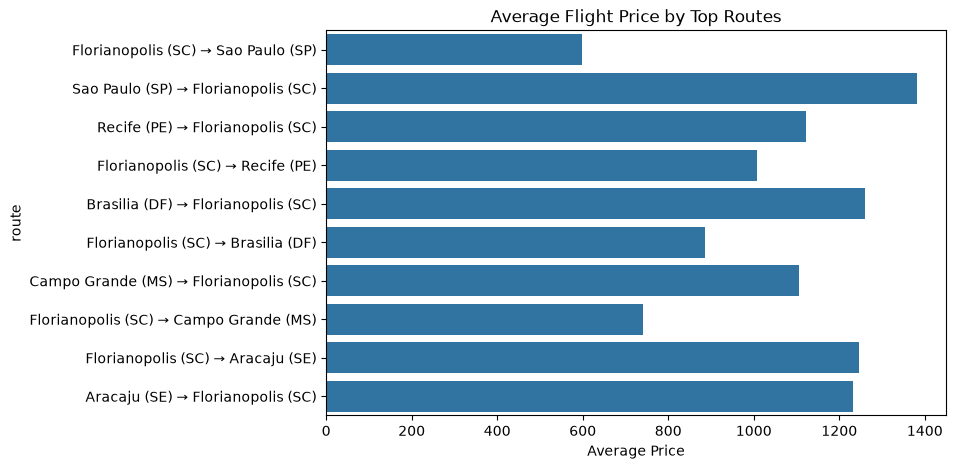

In [74]:
top_routes = route_summary.sort_values("Number_of_flights", ascending = True)

plt.figure(figsize = (8, 5))

sns.barplot(data = top_routes, x = "Average_price", y = "route")

plt.title("Average Flight Price by Top Routes")
plt.xlabel("Average Price")
plt.ylabel = ("Flight Routes")

plt.show()

### 1.7.5 Observation

Flight prices vary considerably by route and direction. Among the top 10 routes, São Paulo → Florianópolis has the highest average price at $1,380.88, while Florianópolis → São Paulo has the lowest at $597.69. This indicates that the origin-destination route is an important factor in determining flight prices.

## 1.8 Flight Price by Date and Month

In this analysis, we examine whether flight prices vary across different months. Understanding temporal patterns can help identify whether the flight booking date provides useful information for flight price prediction.

### 1.8.1 Check and Convert Date

Before performing time-based analysis, we verify that the date column is stored in the correct datetime format.

In [76]:
flights["date"].dtype

<StringDtype(storage='python', na_value=nan)>

In [80]:
flights["date"] = pd.to_datetime(flights["date"])
flights["date"].head()

0   2019-09-26
1   2019-09-30
2   2019-10-03
3   2019-10-04
4   2019-10-10
Name: date, dtype: datetime64[us]

### 1.8.2 Create Month Features

We extract the month number and month name from the flight date to analyze monthly price patterns.

In [81]:
flights["month"] = flights["date"].dt.month

flights["month_name"] = flights["date"].dt.strftime("%B")

flights[["date", "month", "month_name"]].head(10)

,date,month,month_name
0,2019-09-26,9,September
1,2019-09-30,9,September
2,2019-10-03,10,October
3,2019-10-04,10,October
4,2019-10-10,10,October
5,2019-10-12,10,October
6,2019-10-17,10,October
7,2019-10-20,10,October
8,2019-10-24,10,October
9,2019-10-26,10,October


### 1.8.3 Monthly Flight Price Summary

We calculate the number of flights, average price, and median price for each month.

In [84]:
monthly_price_summary = flights.groupby(["month", "month_name"])["price"].agg(
    Number_of_flights = "count",
    Average_price = "median",
    Median_price = "median"
).round(2).reset_index().sort_values("month")

monthly_price_summary

,month,month_name,Number_of_flights,Average_price,Median_price
0,1,January,25587,898.04,898.04
1,2,February,22387,899.60,899.60
2,3,March,22741,908.17,908.17
3,4,April,22607,898.67,898.67
4,5,May,20968,906.59,906.59
5,6,June,19061,908.17,908.17
6,7,July,20113,908.17,908.17
7,8,August,17866,904.00,904.00
8,9,September,19468,899.60,899.60
9,10,October,28980,899.60,899.60


### Observation

- Average flight prices remain relatively stable throughout the year, ranging from 898.04 to 908.17.
- March, June, and July have the highest average price (908.17), while January has the lowest (898.04).
- Flight volume varies more noticeably, with October recording the highest number of flights (28,980) and August the lowest (17,866).
- Overall, the data does not show strong seasonal variation in flight prices.

In [85]:
flights['date'].head()

0   2019-09-26
1   2019-09-30
2   2019-10-03
3   2019-10-04
4   2019-10-10
Name: date, dtype: datetime64[us]

In [87]:
flights['day_name'] = flights['date'].dt.day_name()
flights[['date', 'day_name']].head()


,date,day_name
0,2019-09-26,Thursday
1,2019-09-30,Monday
2,2019-10-03,Thursday
3,2019-10-04,Friday
4,2019-10-10,Thursday


In [88]:
price_by_day = flights.groupby('day_name')['price'].agg(No_of_flights = 'count',
                                                        Average_price = 'mean', 
                                                        Minimum_price = 'min',
                                                        Maximum_price = 'max').round(2).reset_index()

price_by_day

,day_name,No_of_flights,Average_price,Minimum_price,Maximum_price
0,Friday,33880,983.00,301.51,1718.28
1,Monday,34108,985.57,301.51,1718.28
2,Saturday,33868,985.28,301.51,1718.28
3,Sunday,34088,984.23,301.51,1718.28
4,Thursday,135944,930.23,301.51,1754.17


## Observartion

Average flight prices are fairly stable across the available weekdays, ranging from 930.23 on Thursday to 985.57 on Monday. However, the dataset contains a much larger number of Thursday records (135,944) compared with other days (~34,000), so flight counts should not be used to infer weekday demand.

## 1.9 Bivariate Analysis

Bivariate analysis examines the relationship between two variables. In this section, we focus on the relationship between flight price and the main numerical features to identify variables that may be useful for price prediction.

In [92]:
flights.select_dtypes(include='number').columns

Index(['travelCode', 'userCode', 'price', 'time', 'distance', 'month'], dtype='str')

In [91]:
flights['date'].dt.day_name().value_counts()

date
Thursday    135944
Monday       34108
Sunday       34088
Friday       33880
Saturday     33868
Name: count, dtype: int64